In [1]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

In [2]:
from src.paths import DATA_DIR
from src.Qlassifier.prediction import run_tf_idf

/home/ykip10/projects/Qlassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
subjects = ["chemistry", "specialist_mathematics"]
exams = ["2023", "2023_2"]

results = []
for subject, exam in zip(subjects, exams):
    subject_path = DATA_DIR / subject
    exam_path = subject_path / "past_exams" / f"{exam}.pdf"
    result = run_tf_idf(exam_path, subject=subject, include_report=False)
    results.append(result)

/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:93: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


## Evaluation

Since I am no expert in chemistry, I supplied GPT-5 with the necessary documents and asked it to hand-label the best topic classificaitons for us. Unfortunately, for whatever reason, gpt-5 could only reliably label MCQ questions and wasn't very helpful for short answer ones. But alas, even the mcq was of very low quality - by my calculations even worse than this rudimentary TF-IDF approach - as i detected with my limited chemistry knowledge. So, I will hand label on this occasion to the best of my ability, with the help of GPT-5 on individual questions, one at a time.

In [4]:
true_topic_mcq = [
    0, 2, 6, 5, 10, 9, 0, 4, 0, 4,
    3, 3, 6, 4, 0, 9, 1, 9, 6, 8,
    10 ,2, 6, 2, 5, 11, 12, 2, 9, 2,
]

true_topic_indices = true_topic_mcq + [
    6, 7, 7, 6, 6, 2, 2, 2, 2,   # Q1
    6, 10, 10, 10, 6, 10, 6, 10, # Q2
    0, 0, 0, 0, 0, 6,            # Q3
    7, 6, 7, 7, 7,               # Q4
    0, 4, 4, 3,                  # Q5
    2, 2, 2, 2, 2,               # Q6 
    9, 9, 9, 9, 9,               # Q7
    3, 11, 11, 1, 1, 12, 11, 12, # Q8
    5, 5                         # Q9
]

chem_res = results[0]
chem_res.correct_topics=true_topic_indices
chem_df = chem_res.pred_df

In [5]:
round(chem_res.summary(by="topic"), 2)

,Carbon-based fuels,Measuring changes in chemical reactions,Primary galvanic cells and fuel cells as sources of energy,Rates of chemical reactions,Extent of chemical reactions,Production of chemicals using electrolysis,"Structure, nomenclature and properties of organic compounds",Reactions of organic compounds,Laboratory analysis of organic compounds,Instrumental analysis of organic compounds,Medicinal chemistry,Investigation design,Scientific evidence,Science communication
Predicted Topic Counts,14.00,6.00,4.00,2.00,9.00,22.00,2.00,9.00,0.00,9.00,4.00,1.00,0.00,0.0
Predicted Topic Proportions,0.17,0.07,0.05,0.02,0.11,0.27,0.02,0.11,0.00,0.11,0.05,0.01,0.00,0.0
Topic Count,10.00,3.00,14.00,4.00,5.00,4.00,12.00,6.00,1.00,9.00,7.00,4.00,3.00,0.0
Topic Proportion,0.12,0.04,0.17,0.05,0.06,0.05,0.15,0.07,0.01,0.11,0.09,0.05,0.04,0.0
Precision,0.57,0.50,1.00,0.50,0.56,0.18,1.00,0.33,0.00,1.00,0.50,1.00,0.00,0.0
Recall,0.80,1.00,0.29,0.25,1.00,1.00,0.17,0.50,0.00,1.00,0.29,0.25,0.00,0.0
F1-Score,0.67,0.67,0.44,0.33,0.71,0.31,0.29,0.40,0.00,1.00,0.36,0.40,0.00,0.0


In [6]:
round(chem_res.summary(by="overall"), 2)

Accuracy           0.51
Top 3 Accuracy     0.67
Macro-Precision    0.51
Macro-Recall       0.47
Macro-F1-Score     0.40
dtype: float64

In [7]:
incorrect_chem = chem_df[chem_df["pred_topic_idx"] != chem_df["true_topic_idx"]]
correct_chem = chem_df[chem_df["pred_topic_idx"] == chem_df["true_topic_idx"]]
incorrect_chem.head(5)

,label,text,pred_topic,pred_topic_idx,confidence,true_topic_idx
2,Question 3,"Molecules X, and all have the same number of c...",Reactions of organic compounds,7,0.234810,6
10,Question 11,student conducted an experiment to determine t...,Extent of chemical reactions,4,0.306692,3
12,Question 13,Which molecule can exist as both cis and trans...,Medicinal chemistry,10,0.227458,6
14,Question 15,Consider two types of drone: petrol-powered an...,Production of chemicals using electrolysis,5,0.349906,0
19,Question 20,Which one of the following is always correct w...,Production of chemicals using electrolysis,5,0.304880,8


Let's check how good our confidence metric is.

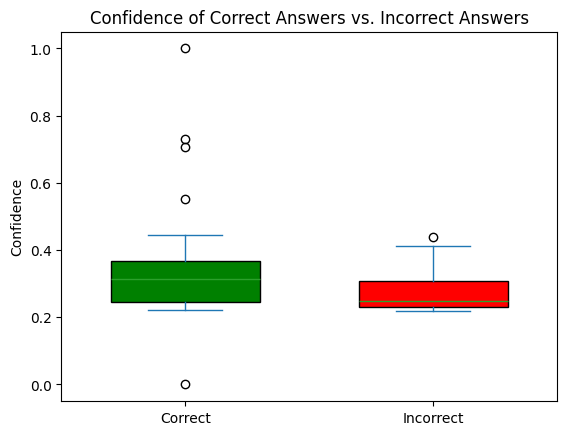

In [8]:
chem_res.plot_conf()

A rough threshold for a "confident estimate" might be around 0.6.

Our goal isn't really to JUST assign a question to a topic; this is a flawed problem design, since questions may belong to multiple topics. The hand labelling above was just what I deemed to be the single BEST answer. In reality, its the distribution of the weights for each topic that we are interested in. We also didn't test short answer (since the labelling is tedious to say the least, and the one "true label" is even more ambiguous). 

So we incorporate an ordinary accuracy metric plus something to determine how sensical the answers are (percentage of time the predicted topic is within the top3 most similar topics). 

In [9]:
evaluate_predictions(chem_df, cos_chem)

NameError: name 'evaluate_predictions' is not defined

Check MCQ accuracy.

In [ ]:
evaluate_predictions(mcq_chem, cos_chem)

--EVAL METRICS--
Exam-only accuracy: 73.33%
True topic in top 3 question prediction 90.00%


We move on to a mathematics subject, in which we expect our 'model' to perform FAR worse, since we don't have LaTeX data and plenty of the context is in the LaTeX for math exams, especially relative to chemistry ones. This one I hand label reliably.

In [ ]:
mcq_labels = [
    0, 1, 1, 2, 2, 4, 4, 4, 7, 3, 
    3, 5, 5, 6, 6, 8, 6, 7, 9, 11,
]

ground_truth = mcq_labels + [
    1, 3, 3, 3, 7, 8, 3, 3,            # Q1
    2, 2, 2, 2, 2, 2, 2, 2,            # Q2
    3, 3, 3, 3, 3, 3,                  # Q3
    4, 4, 4, 4, 4, 4, 1, 4,            # Q4
    6, 6, 7, 7, 7, 7,                  # Q5
    11, 11, 11, 12, 12, 12, 12, 12, 10 # Q6  

]

math_df = dfs[1]
cos_math = cos_lst[1]
math_df["true_topic_idx"] = ground_truth
mcq_math = math_df.loc[:19]
math_df.head(5)

,label,text,comments,total_marks,pred_topic,pred_topic_idx,confidence,true_topic_idx
0,Question 1,Consider the following statement. ‘If my footb...,,1,Discrete mathematics: Logic and proof,0,0.312597,0
1,Question 2,The graph of ax bx has asymptotes given by and...,,1,"Data analysis, probability and statistics: Dis...",10,0.025168,1
2,Question 3,"In the interval π π the graph of sec( ), where...",,1,"Data analysis, probability and statistics: Con...",11,0.373191,1
3,Question 4,"If − 1) ai where is non-zero real constant, t...",,1,"Data analysis, probability and statistics: Dis...",9,1.000000,2
4,Question 5,Let be complex number where Re( and Im( 0. Giv...,,1,"Algebra, number and structure: Complex numbers",2,0.251177,2


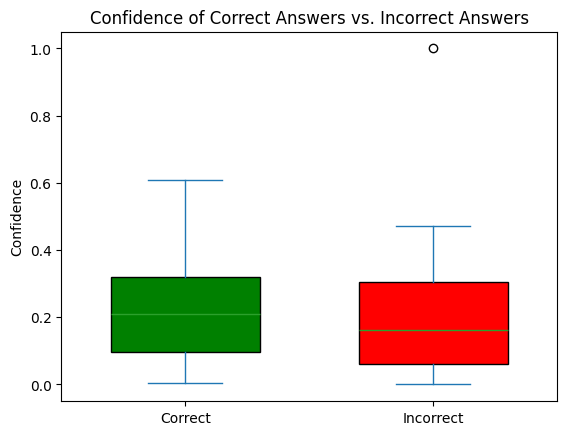

In [ ]:
plot_conf(math_df)

We can see that confidence means less in this case. But it does still have some meaning, since we see decent evidence of separation b/w the two classes in the extrema. Regardless the metric is clearly flawed since the maximum confidence belonged to an incorrect answer. We take it with a grain of salt (perhaps weigh by confidence very lightly when incorporating with other models).

In [ ]:
evaluate_predictions(math_df, cos_math)

--EVAL METRICS--
Exam-only accuracy: 43.08%
True topic in top 3 question prediction 63.08%


In [ ]:
evaluate_predictions(mcq_math, cos_math)

--EVAL METRICS--
Exam-only accuracy: 45.00%
True topic in top 3 question prediction 60.00%


As expected! These results will serve as our baseline. 

In [ ]:
math_df.to_csv("results/tf_idf_math_out.csv")
chem_df.to_csv("results/tf_idf_chem_out.csv")